In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Clean_Dataset.csv")
df_business = pd.read_csv("business.csv")
df_economy = pd.read_csv("economy.csv")

In [58]:
df.head()

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        300153 non-null  int64  
 1   airline           300153 non-null  object 
 2   flight            300153 non-null  object 
 3   source_city       300153 non-null  object 
 4   departure_time    300153 non-null  object 
 5   stops             300153 non-null  object 
 6   arrival_time      300153 non-null  object 
 7   destination_city  300153 non-null  object 
 8   class             300153 non-null  object 
 9   duration          300153 non-null  float64
 10  days_left         300153 non-null  int64  
 11  price             300153 non-null  int64  
dtypes: float64(1), int64(3), object(8)
memory usage: 27.5+ MB


In [3]:
df.drop('Unnamed: 0',axis = 1,inplace = True)

In [28]:
df.duplicated().sum()

np.int64(0)

In [62]:
cat_column_names = df.select_dtypes('object').columns.tolist()
print("Number of unique values of columns:")
for col in cat_column_names:
    print(col,":")
    print(df[col].nunique())
    print(df[col].unique(),"\n")

Number of unique values of columns:
airline :
6
['SpiceJet' 'AirAsia' 'Vistara' 'GO_FIRST' 'Indigo' 'Air_India'] 

flight :
1561
['SG-8709' 'SG-8157' 'I5-764' ... '6E-7127' '6E-7259' 'AI-433'] 

source_city :
6
['Delhi' 'Mumbai' 'Bangalore' 'Kolkata' 'Hyderabad' 'Chennai'] 

departure_time :
6
['Evening' 'Early_Morning' 'Morning' 'Afternoon' 'Night' 'Late_Night'] 

stops :
3
['zero' 'one' 'two_or_more'] 

arrival_time :
6
['Night' 'Morning' 'Early_Morning' 'Afternoon' 'Evening' 'Late_Night'] 

destination_city :
6
['Mumbai' 'Bangalore' 'Kolkata' 'Hyderabad' 'Chennai' 'Delhi'] 

class :
2
['Economy' 'Business'] 



In [4]:
#Uçuş kodu price üzerinde etkisiz olduğu ve encode edilemeyecek kadar unique değere sahip olduğu için drop edildi.
df.drop('flight', axis = 1, inplace = True)

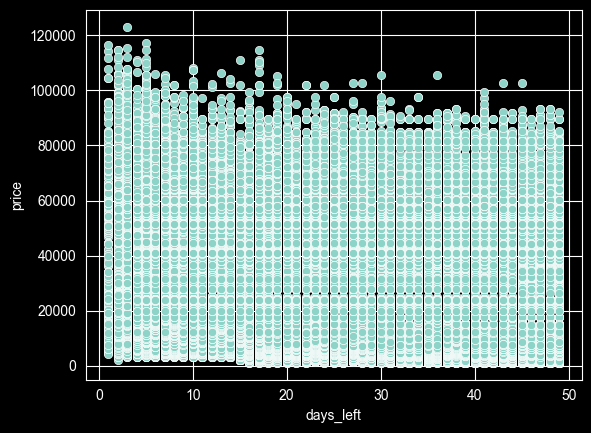

In [12]:
sns.scatterplot(data= df, x= 'days_left', y= 'price')
plt.show()

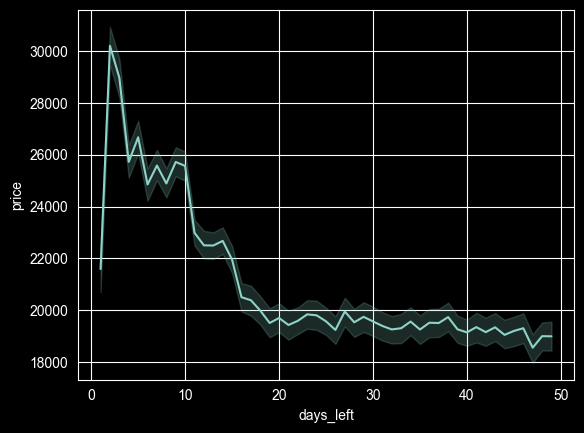

In [67]:
sns.lineplot(data=df, x= 'days_left', y= 'price')
plt.show()

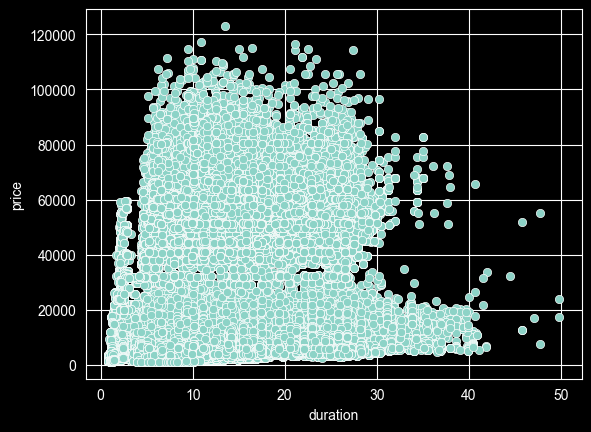

In [13]:
sns.scatterplot(data=df, x='duration', y='price')
plt.show()

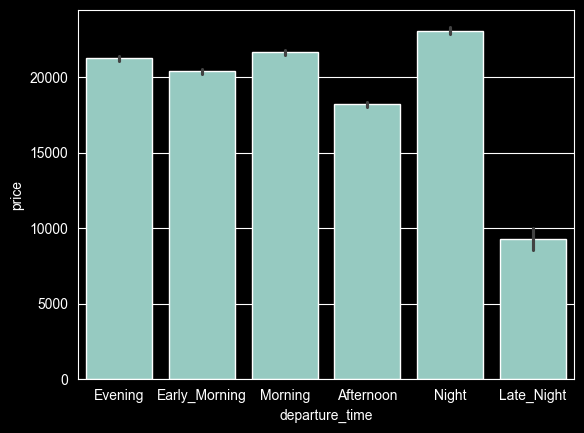

In [14]:
sns.barplot(data=df, x='departure_time', y='price')
plt.show()

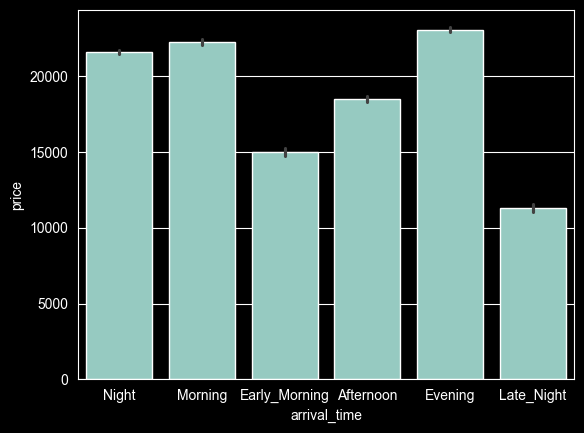

In [15]:
sns.barplot(data=df, x='arrival_time', y='price')
plt.show()

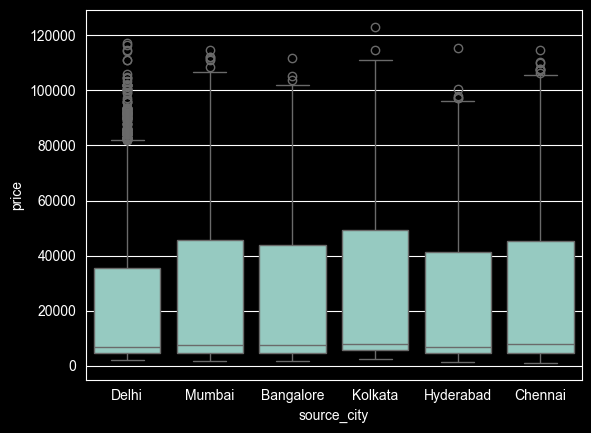

In [34]:
sns.boxplot(data=df, x='source_city', y='price')
plt.show()

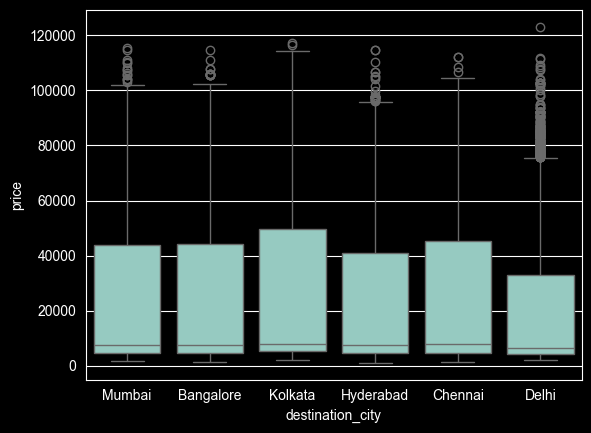

In [35]:
sns.boxplot(data=df, x='destination_city', y='price')
plt.show()

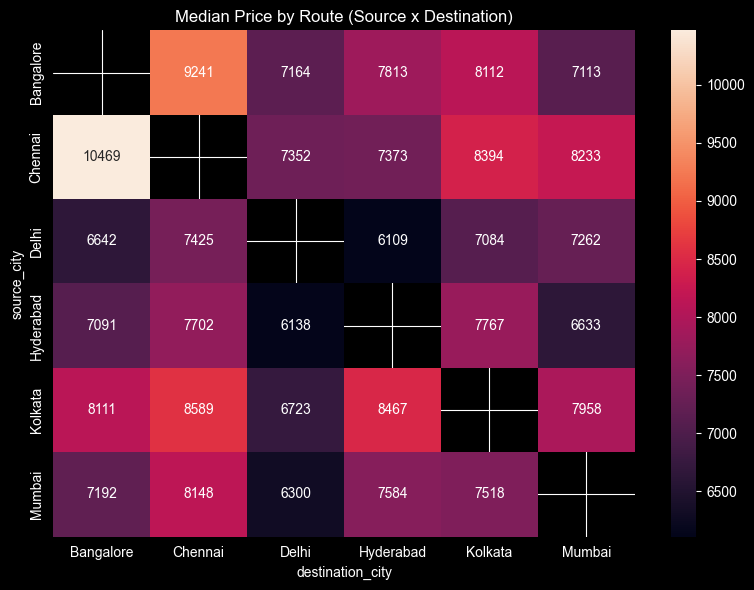

In [36]:
pivot = df.pivot_table(index="source_city", columns="destination_city", values="price", aggfunc="median")

plt.figure(figsize=(8,6))
sns.heatmap(pivot, annot=True, fmt=".0f")
plt.title("Median Price by Route (Source x Destination)")
plt.tight_layout()
plt.show()

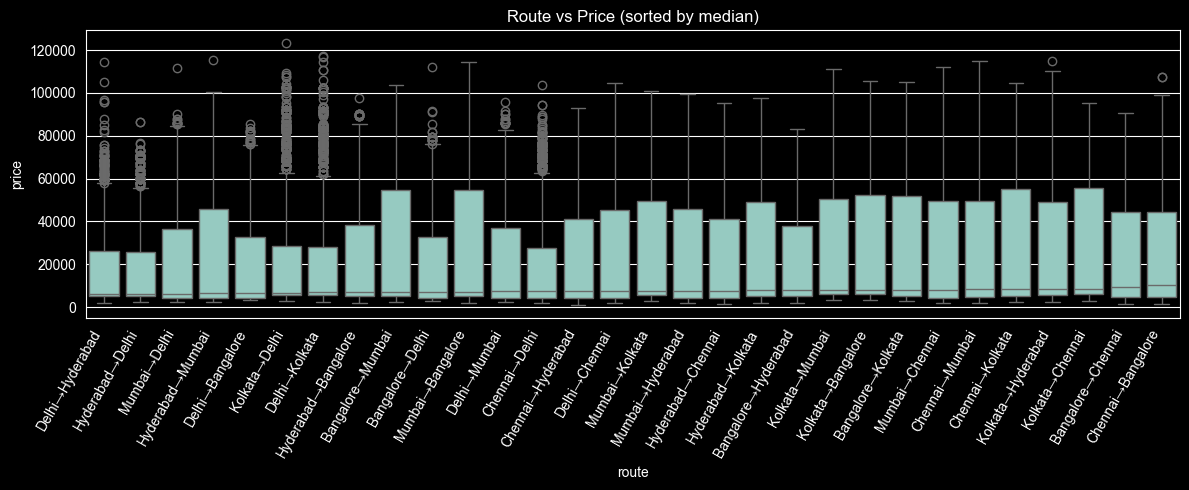

In [5]:
df["route"] = df["source_city"].astype(str) + "→" + df["destination_city"].astype(str)

plt.figure(figsize=(12,5))
order = df.groupby("route")["price"].median().sort_values().index
sns.boxplot(data=df, x="route", y="price", order=order)
plt.title("Route vs Price (sorted by median)")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

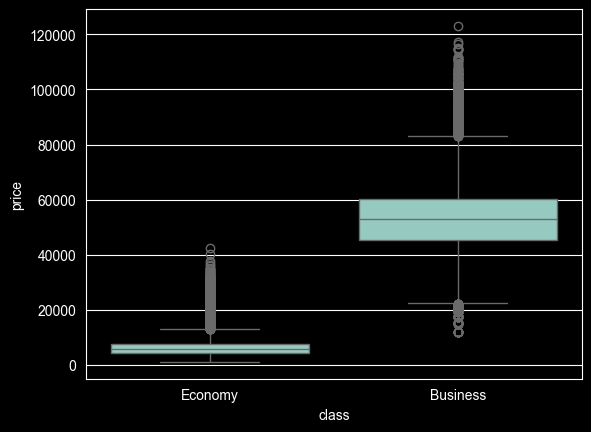

In [64]:
sns.boxplot(data= df, x='class', y='price')
plt.show()

In [6]:
class_map = {
    "Economy": 0,
    "Business": 1
}

df['class'] = df['class'].map(class_map)

In [7]:
stops_map = {
    "zero": 0,
    "one": 1,
    "two_or_more": 2
}

df['stops'] = df['stops'].map(stops_map)

In [10]:
X = df.drop(['price','route'], axis=1)
y = df['price']

In [34]:
X.head()

,airline,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left
0,SpiceJet,Delhi,Evening,0,Night,Mumbai,0,2.17,1
1,SpiceJet,Delhi,Early_Morning,0,Morning,Mumbai,0,2.33,1
2,AirAsia,Delhi,Early_Morning,0,Early_Morning,Mumbai,0,2.17,1
3,Vistara,Delhi,Morning,0,Afternoon,Mumbai,0,2.25,1
4,Vistara,Delhi,Morning,0,Morning,Mumbai,0,2.33,1


In [23]:
y.head()

0    5953
1    5953
2    5956
3    5955
4    5955
Name: price, dtype: int64

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [33]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

num_cols = X.select_dtypes(include="number").columns
cat_cols = X.select_dtypes("object").columns

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categoric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore", drop="first"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categoric_transformer, cat_cols)
    ],
    remainder="passthrough"
)

In [27]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor

models = [
    ("linear_regressor", LinearRegression()),
    ("Ada_boost_regressor", AdaBoostRegressor()),
    ("Decision_tree_regressor", DecisionTreeRegressor()),
    ("XGBoost_regressor", XGBRegressor())
]

In [3]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
def print_scores(y_test, y_pred):
    print("r2 score: ", r2_score(y_test, y_pred))
    print("mean squared error: ", mean_squared_error(y_test, y_pred))
    print("mean absolute error: ", mean_absolute_error(y_test, y_pred))

In [34]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
for name, model in models:
    pipe = Pipeline(steps=[
    ("preprocessor", preprocess),
    ("regressor", model)
    ])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    print(name)
    print_scores(y_test, y_pred)
    print("="*50)

linear_regressor
r2 score:  0.9101093334910807
mean squared error:  46349246.993568785
mean absolute error:  4499.954779230366
Ada_boost_regressor
r2 score:  0.9297697996714163
mean squared error:  36211956.45617284
mean absolute error:  3904.452085742896
Decision_tree_regressor
r2 score:  0.9748143222502053
mean squared error:  12986189.156911368
mean absolute error:  1198.6405358102677
XGBoost_regressor
r2 score:  0.9757385849952698
mean squared error:  12509625.0
mean absolute error:  2018.564208984375


In [35]:
X2 = df.drop(['price', 'source_city', 'destination_city'], axis=1)
y2 = df['price']
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.25, random_state=42)

num_cols = X2.select_dtypes(include="number").columns
cat_cols = X2.select_dtypes("object").columns

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categoric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore", drop="first"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categoric_transformer, cat_cols)
    ]
)

In [36]:
for name, model in models:
    pipe = Pipeline(steps=[
    ("preprocessor", preprocess),
    ("regressor", model)
    ])
    pipe.fit(X2_train, y2_train)
    y2_pred = pipe.predict(X2_test)
    print(name)
    print_scores(y2_test, y2_pred)
    print("="*50)

linear_regressor
r2 score:  0.9110824227076594
mean squared error:  45847504.663718425
mean absolute error:  4499.919913100826
Ada_boost_regressor
r2 score:  0.9279628466416087
mean squared error:  37143653.989820786
mean absolute error:  3916.53005690061
Decision_tree_regressor
r2 score:  0.9764262289995309
mean squared error:  12155060.999154514
mean absolute error:  1182.136178076289
XGBoost_regressor
r2 score:  0.9755477905273438
mean squared error:  12608008.0
mean absolute error:  1999.4217529296875


In [42]:
df['price'].median()

np.float64(7425.0)

In [44]:
#decision tree MAE / price columns median value * 100
1181/7425*100

15.905723905723907

In [45]:
ape = np.abs((y_test - y_pred) / y_test)
mdape = np.median(ape) * 100

wape = (np.abs(y_test - y_pred).sum() / y_test.sum()) * 100

print("MdAPE %:", mdape)
print("WAPE  %:", wape)

MdAPE %: 9.92858189230243
WAPE  %: 9.65510545954928


In [8]:
#Ablasyon Testi

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from xgboost import XGBRegressor

X = df.drop(columns = ['price', 'source_city', 'destination_city'], axis=1)
y = df['price']

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categoric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore", drop="first"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, make_column_selector(dtype_include="number")),
        ("cat", categoric_transformer, make_column_selector(dtype_exclude="number"))
    ],
    remainder="passthrough"
)

pipe = Pipeline(steps=[
    ("preprocessor", preprocess),
    ("regressor", XGBRegressor())
    ])

drop_cols = ["days_left", "class", "stops", "duration", "route"]

for col in drop_cols:
    X_temp = X.drop(columns=[col], axis=1)

    X_train, X_test, y_train, y_test = train_test_split(X_temp, y, test_size=0.25, random_state=42)

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    print(f"{col} olmadan çıkan r2 skoru: ", r2_score(y_test, y_pred))
    print("="*50)

days_left olmadan çıkan r2 skoru:  0.9647661447525024
class olmadan çıkan r2 skoru:  0.34150075912475586
stops olmadan çıkan r2 skoru:  0.9751129746437073
duration olmadan çıkan r2 skoru:  0.9670568704605103
route olmadan çıkan r2 skoru:  0.9621675610542297


In [9]:
#Permutation Importance Testi

from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
import pandas as pd

X = df.drop(columns=["price"])
y = df["price"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

pipe.fit(X_train, y_train)

r = permutation_importance(pipe, X_test, y_test, n_repeats=10, random_state=42, scoring="r2")
imp = pd.Series(r.importances_mean, index=X_test.columns).sort_values(ascending=False)
imp.head(15)

class               1.789141
duration            0.115250
airline             0.033461
days_left           0.026048
route               0.021931
destination_city    0.008765
source_city         0.008257
arrival_time        0.007525
departure_time      0.006538
stops               0.003755
dtype: float64

In [3]:
df_business.head()

,date,airline,ch_code,num_code,dep_time,from,time_taken,stop,arr_time,to,price
0,11-02-2022,Air India,AI,868,18:00,Delhi,02h 00m,non-stop,20:00,Mumbai,"25,612"
1,11-02-2022,Air India,AI,624,19:00,Delhi,02h 15m,non-stop,21:15,Mumbai,"25,612"
2,11-02-2022,Air India,AI,531,20:00,Delhi,24h 45m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,20:45,Mumbai,"42,220"
3,11-02-2022,Air India,AI,839,21:25,Delhi,26h 30m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,23:55,Mumbai,"44,450"
4,11-02-2022,Air India,AI,544,17:15,Delhi,06h 40m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,23:55,Mumbai,"46,690"


In [4]:
df_business.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93487 entries, 0 to 93486
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   date        93487 non-null  object
 1   airline     93487 non-null  object
 2   ch_code     93487 non-null  object
 3   num_code    93487 non-null  int64 
 4   dep_time    93487 non-null  object
 5   from        93487 non-null  object
 6   time_taken  93487 non-null  object
 7   stop        93487 non-null  object
 8   arr_time    93487 non-null  object
 9   to          93487 non-null  object
 10  price       93487 non-null  object
dtypes: int64(1), object(10)
memory usage: 7.8+ MB


In [4]:
df_economy.drop('date',axis=1,inplace=True)
df_business.drop('date',axis=1,inplace=True)

In [8]:
cat_column_names2 = df_business.select_dtypes('object').columns.tolist()
print("Number of unique values of columns:")
for col in cat_column_names2:
    print(col,":")
    print(df_business[col].nunique())
    print(df_business[col].unique(),"\n")

Number of unique values of columns:
airline :
2
['Air India' 'Vistara'] 

ch_code :
2
['AI' 'UK'] 

dep_time :
166
['18:00' '19:00' '20:00' '21:25' '17:15' '19:50' '21:15' '18:40' '20:35'
 '21:35' '17:20' '20:40' '16:15' '16:05' '20:15' '16:55' '17:30' '17:35'
 '17:25' '07:00' '08:00' '09:00' '14:30' '17:50' '05:55' '13:40' '12:55'
 '08:50' '17:45' '07:05' '18:30' '04:55' '17:10' '09:30' '16:30' '09:45'
 '08:10' '10:15' '07:30' '17:40' '14:45' '13:20' '11:40' '14:50' '10:55'
 '11:00' '10:20' '09:50' '10:25' '06:05' '13:30' '07:10' '14:15' '09:05'
 '08:05' '16:50' '14:10' '12:10' '06:50' '19:55' '15:55' '11:10' '14:20'
 '13:00' '15:30' '06:10' '06:30' '13:15' '05:30' '04:50' '16:45' '08:40'
 '21:50' '05:45' '12:50' '18:20' '10:40' '20:30' '11:55' '21:40' '22:00'
 '15:05' '12:00' '23:30' '18:55' '15:00' '21:10' '06:00' '06:15' '06:40'
 '13:45' '09:25' '11:20' '19:10' '05:15' '21:30' '19:20' '18:35' '19:45'
 '20:55' '10:35' '16:00' '15:35' '12:25' '12:15' '07:15' '08:45' '10:45'
 '14:40' 

In [5]:
def hhmm_to_min(s):
    t = pd.to_datetime(s, format="%H:%M", errors="coerce")
    return t.dt.hour * 60 + t.dt.minute

df_business["dep_min"] = hhmm_to_min(df_business["dep_time"])
df_business["arr_min"] = hhmm_to_min(df_business["arr_time"])

df_economy["dep_min"] = hhmm_to_min(df_economy["dep_time"])
df_economy["arr_min"] = hhmm_to_min(df_economy["arr_time"])

In [6]:
for col in ["dep_min", "arr_min"]:
    df_business[f"{col}_sin"] = np.sin(2*np.pi*df_business[col]/1440)
    df_business[f"{col}_cos"] = np.cos(2*np.pi*df_business[col]/1440)
    df_economy[f"{col}_sin"] = np.sin(2*np.pi*df_economy[col]/1440)
    df_economy[f"{col}_cos"] = np.cos(2*np.pi*df_economy[col]/1440)

In [7]:
df_business.drop(['dep_time', 'arr_time', 'dep_min', 'arr_min'], axis=1, inplace=True)
df_economy.drop(['dep_time', 'arr_time', 'dep_min', 'arr_min'], axis=1, inplace=True)

In [8]:
import re
import numpy as np

def parse_time_taken_to_min(x):
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return np.nan
    x = str(x).strip()
    m = re.search(r"(\d+)\s*h", x)
    n = re.search(r"(\d+)\s*m", x)
    hours = int(m.group(1)) if m else 0
    mins  = int(n.group(1)) if n else 0
    return hours*60 + mins

df_business["time_taken_min"] = df_business["time_taken"].apply(parse_time_taken_to_min)
df_economy["time_taken_min"] = df_economy["time_taken"].apply(parse_time_taken_to_min)

In [9]:
df_business.drop('time_taken', axis=1, inplace=True)
df_economy.drop('time_taken', axis=1, inplace=True)

In [10]:
def map_stops(x):
    if pd.isna(x):
        return np.nan

    s = str(x).lower()
    # satır atlama/tab gibi kirleri temizle
    s = s.replace("\n", " ").replace("\t", " ").strip()

    if "non-stop" in s or "non stop" in s:
        return 0
    if "2+-stop" in s or "2+ stop" in s or "2+" in s:
        return 2
    if "1-stop" in s or "1 stop" in s:
        return 1

    return np.nan  # beklenmeyen formatlar için

df_business["stops"] = df_business["stop"].apply(map_stops)
df_economy["stops"] = df_economy["stop"].apply(map_stops)

In [11]:
df_business.drop('stop', axis=1, inplace=True)
df_economy.drop('stop', axis=1, inplace=True)

In [12]:
df_business['price'] = (
    df_business['price'].astype(str)
    .str.replace(",","",regex=False)
    .str.strip()
).astype(int)

df_economy['price'] = (
    df_economy['price'].astype(str)
    .str.replace(",","",regex=False)
    .str.strip()
).astype(int)

In [34]:
df_business.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93487 entries, 0 to 93486
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   airline         93487 non-null  object 
 1   ch_code         93487 non-null  object 
 2   num_code        93487 non-null  int64  
 3   from            93487 non-null  object 
 4   to              93487 non-null  object 
 5   price           93487 non-null  int64  
 6   dep_min_sin     93487 non-null  float64
 7   dep_min_cos     93487 non-null  float64
 8   arr_min_sin     93487 non-null  float64
 9   arr_min_cos     93487 non-null  float64
 10  time_taken_min  93487 non-null  int64  
 11  stops           93487 non-null  int64  
dtypes: float64(4), int64(4), object(4)
memory usage: 8.6+ MB


In [56]:
df_economy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 206774 entries, 0 to 206773
Data columns (total 12 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   airline         206774 non-null  object 
 1   ch_code         206774 non-null  object 
 2   num_code        206774 non-null  int64  
 3   from            206774 non-null  object 
 4   to              206774 non-null  object 
 5   price           206774 non-null  int64  
 6   dep_min_sin     206774 non-null  float64
 7   dep_min_cos     206774 non-null  float64
 8   arr_min_sin     206774 non-null  float64
 9   arr_min_cos     206774 non-null  float64
 10  time_taken_min  206774 non-null  int64  
 11  stops           206774 non-null  int64  
dtypes: float64(4), int64(4), object(4)
memory usage: 18.9+ MB


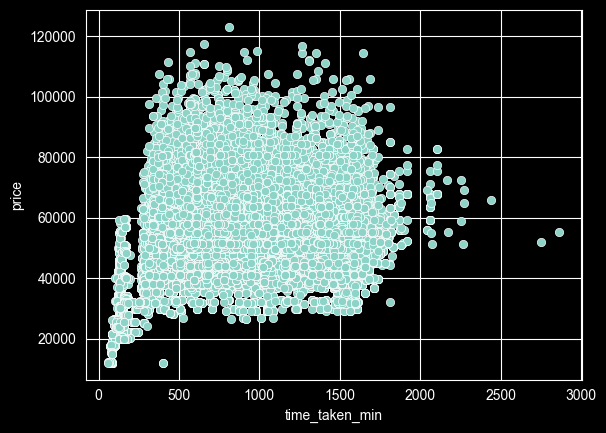

In [13]:
sns.scatterplot(data= df_business, x= 'time_taken_min', y= 'price')
plt.show()

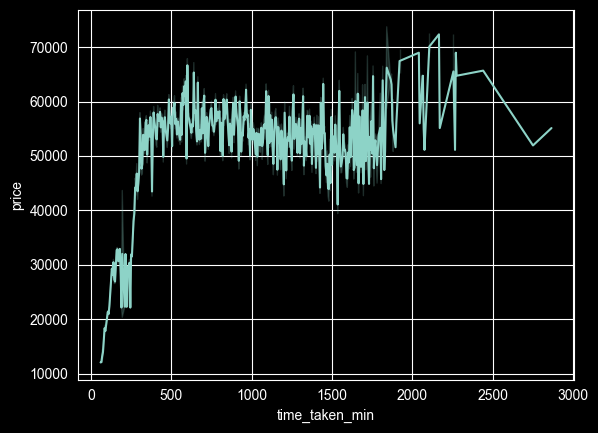

In [14]:
#for business class
sns.lineplot(data= df_business, x= 'time_taken_min', y= 'price')
plt.show()

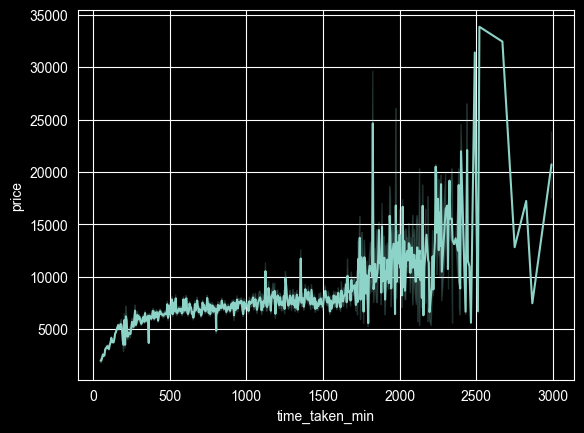

In [15]:
#for economy class
sns.lineplot(data= df_economy, x= 'time_taken_min', y= 'price')
plt.show()

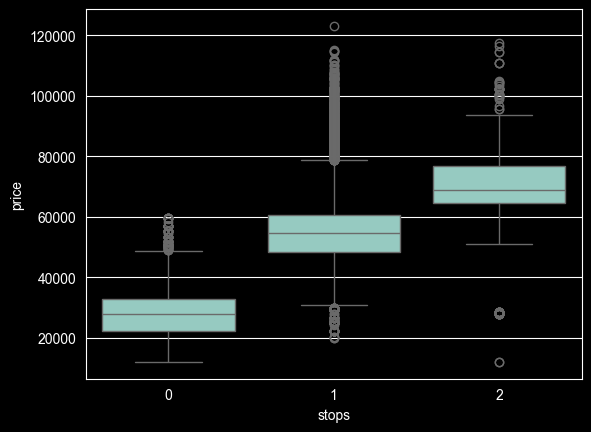

In [37]:
sns.boxplot(data= df_business, x= 'stops', y= 'price')
plt.show()

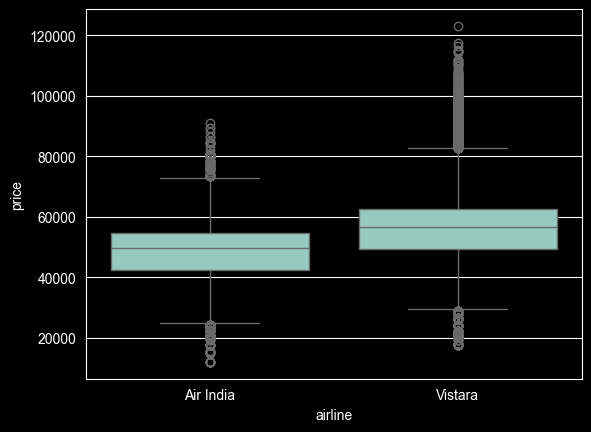

In [38]:
sns.boxplot(data= df_business, x= 'airline', y= 'price')
plt.show()

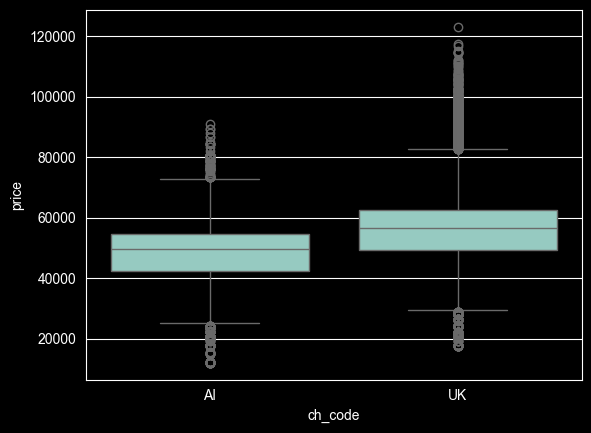

In [39]:
sns.boxplot(data= df_business, x= 'ch_code', y= 'price')
plt.show()

In [16]:
df_business.drop('ch_code', axis=1, inplace=True)
df_economy.drop('ch_code', axis=1, inplace=True)

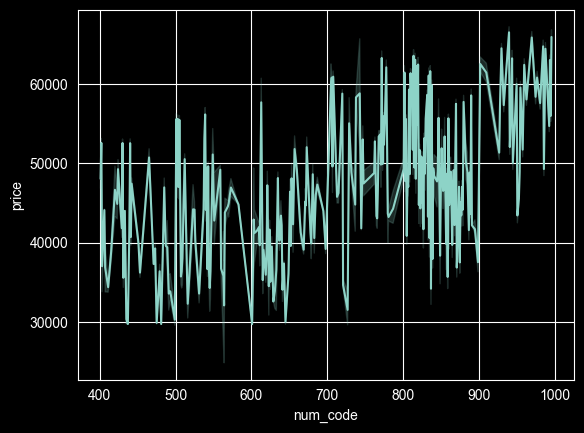

In [44]:
sns.lineplot(data= df_business, x= 'num_code', y= 'price')
plt.show()

In [14]:
from sklearn.model_selection import train_test_split

Xb = df_business.drop('price',axis=1)
yb = df_business['price']

Xe = df_economy.drop('price', axis=1)
ye = df_economy['price']

Xb_train, Xb_test, yb_train, yb_test = train_test_split(Xb, yb, test_size=0.2, random_state=42)
Xe_train, Xe_test, ye_train, ye_test = train_test_split(Xe, ye, test_size=0.2, random_state=42)

In [15]:
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from xgboost import XGBRegressor


numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categoric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore", drop="first"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, make_column_selector(dtype_include="number")),
        ("cat", categoric_transformer, make_column_selector(dtype_exclude="number"))
    ],
    remainder="passthrough"
)

pipe = Pipeline(steps=[
    ("preprocessor", preprocess),
    ("regressor", XGBRegressor())
    ])

In [22]:
pipe.fit(Xb_train, yb_train)
yb_pred = pipe.predict(Xb_test)
print("\nRegression prediction for Business class data\n")
print_scores(yb_test, yb_pred)

print("="*50)

pipe.fit(Xe_train, ye_train)
ye_pred = pipe.predict(Xe_test)
print("Regression prediction for Economy class data\n")
print_scores(ye_test, ye_pred)


Regression prediction for Business class data

r2 score:  0.8797358870506287
mean squared error:  20338286.0
mean absolute error:  2599.331787109375
Regression prediction for Economy class data

r2 score:  0.3811766505241394
mean squared error:  8613399.0
mean absolute error:  2123.414794921875


## Sonuç ve Değerlendirme

Bu projede uçuş verisi kullanılarak `price` tahmini için regresyon modelleri kurulmuştur.

### 1) Clean dataset – Class etkisi
- Clean dataset üzerinde DecisionTree/XGBoost gibi modellerle yüksek performans (yüksek R²) elde edilmiştir.
- Yapılan **ablasyon testi** ile `class` sütunu çıkarıldığında R² skorunun belirgin şekilde düştüğü gözlemlenmiştir.
- **Permutation importance** sonuçları da en baskın açıklayıcı değişkenin `class` olduğunu göstermiştir.
- EDA sırasında da Economy ve Business sınıflarının fiyat dağılımlarının net biçimde ayrıştığı görülmüştür.

**Çıkarım:** Clean dataset’teki yüksek model başarısının ana nedeni `class` değişkenidir.

### 2) Segment bazlı modelleme (Business vs Economy)
Veri sağlayıcının sunduğu Business ve Economy alt veri setleri ayrı ayrı ele alınmıştır:
- Business veri setinde model performansı anlamlı seviyede kalmıştır (R² görece yüksek).
- Economy veri setinde model performansı düşüktür (R² düşük). Bu, Economy segmentinde fiyatların mevcut feature seti ile yeterince açıklanamadığını göstermektedir.

**Çıkarım:** Economy segmentinde fiyat dinamiğini açıklayacak kritik değişkenler veri setinde bulunmadığından, fiyat tahmini daha gürültülü (noisy) kalmaktadır.

### 3) Genel Sonuç
- `class` bilgisi mevcutken fiyat tahmini oldukça güçlüdür.
- `class` etkisi ayrıştırıldığında, özellikle Economy segmentinde tahmin edilebilirlik sınırlıdır.
- Mevcut feature seti, özellikle Economy fiyatları için yeterli açıklayıcı güç sunmamaktadır.

Proje kapsamında veri temizleme, feature engineering, modelleme ve model yorumlama adımları tamamlanmıştır.